# hand2string — Preprocessing Pipeline
Extracts MediaPipe landmarks (hands + pose + face) from How2Sign ASL clips  
and produces windowed `.npy` arrays ready for transformer training.

**Stages:** Download → Landmark extraction (parallel) → Manifest → Windowing → DataLoader → Visualization

## 0 · Imports

In [1]:
import json
import multiprocessing as _mp
import os
import subprocess
import sys
import urllib.request
from functools import partial
from pathlib import Path

import cv2
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from huggingface_hub import snapshot_download
from IPython.display import Markdown, Video, display as ipy_display
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

# ── Repo root (works whether called as __file__ or from notebook) ──────────────
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "hand2string" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

sns.set_theme(style="whitegrid", palette="muted")
print(f"Repo root : {REPO_ROOT}")
print(f"MediaPipe : {mp.__version__}")
print("Imports OK")

Repo root : /home/louis/epfl/ma2/cs/hand2string
MediaPipe : 0.10.33
Imports OK


## 1 · Config & paths

In [2]:
# ── Config ─────────────────────────────────────────────────────────────────────
with open(REPO_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_NAME = "how2sign"
DATA_ROOT    = REPO_ROOT / "data" / DATASET_NAME
OUTPUT_ROOT  = REPO_ROOT / "data" / f"{DATASET_NAME}_landmarks"
WINDOW_DIR   = REPO_ROOT / "data" / f"{DATASET_NAME}_windows"
VIZ_DIR      = REPO_ROOT / "outputs" / "viz"
for d in (OUTPUT_ROOT, WINDOW_DIR, VIZ_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── MediaPipe flags ────────────────────────────────────────────────────────────
USE_HANDS   = cfg["preprocessing"]["mediapipe"]["hands"]
USE_POSE    = cfg["preprocessing"]["mediapipe"]["pose"]
USE_FACE    = cfg["preprocessing"]["mediapipe"]["face"]
FACE_SUBSET = cfg["preprocessing"]["mediapipe"].get("face_subset", "full")
TARGET_FPS  = cfg["preprocessing"]["fps"]

# ── Training ───────────────────────────────────────────────────────────────────
WINDOW_SIZE = cfg["training"]["window_size"]
BATCH_SIZE  = cfg["training"]["batch_size"]

# ── ASL-relevant face landmarks (mouth + eyebrows + eyes + nose) ───────────────
FACE_LANDMARKS_ASL = sorted({
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308,  # lips outer
    78, 95, 88, 178, 87, 14, 317, 402, 318, 324,              # lips inner
    70, 63, 105, 66, 107, 55, 65,                             # left eyebrow
    300, 293, 334, 296, 336, 285, 295,                        # right eyebrow
    33, 160, 158, 133, 153, 144,                              # left eye
    362, 385, 387, 263, 373, 380,                             # right eye
    1, 2, 4, 5, 6,                                            # nose
})

# ── Feature dims ───────────────────────────────────────────────────────────────
HAND_DIM      = 21 * 3   # 63
POSE_DIM      = 33 * 3   # 99
FACE_DIM_FULL = 468 * 3
FACE_DIM_ASL  = len(FACE_LANDMARKS_ASL) * 3
FACE_DIM      = (FACE_DIM_ASL if FACE_SUBSET == "asl" else FACE_DIM_FULL) if USE_FACE else 0

FEAT_DIM = (
    (HAND_DIM * 2 if USE_HANDS else 0) +
    (POSE_DIM     if USE_POSE  else 0) +
    (FACE_DIM     if USE_FACE  else 0)
)

print(f"Dataset : {DATASET_NAME} @ {DATA_ROOT}")
print(f"Output  : {OUTPUT_ROOT}")
print(f"FPS cap : {TARGET_FPS}")
print(f"Window  : {WINDOW_SIZE} frames  |  Batch: {BATCH_SIZE}")
print(f"Face    : {FACE_SUBSET}  ({len(FACE_LANDMARKS_ASL)} landmarks = {FACE_DIM} dims)")
print(f"Feat dim: {FEAT_DIM}  (hands={HAND_DIM*2 if USE_HANDS else 0} + pose={POSE_DIM if USE_POSE else 0} + face={FACE_DIM})")

Dataset : how2sign @ /home/louis/epfl/ma2/cs/hand2string/data/how2sign
Output  : /home/louis/epfl/ma2/cs/hand2string/data/how2sign_landmarks
FPS cap : 60
Window  : 256 frames  |  Batch: 8
Face    : asl  (53 landmarks = 159 dims)
Feat dim: 384  (hands=126 + pose=99 + face=159)


## 2 · Download dataset from HuggingFace

In [ ]:
HF_REPO_ID = "martinctl/how2sign-asl-clips"
print(f"Fetching: {HF_REPO_ID} ...")

local = Path(snapshot_download(HF_REPO_ID, repo_type="dataset"))
df    = pd.read_parquet(local / "metadata.parquet")

print(f"Clips   : {len(df)}")
print(f"Columns : {df.columns.tolist()}")
print(f"Splits  : {df['split'].value_counts().to_dict()}")
df.head()

Fetching: martinctl/how2sign-asl-clips ...


Fetching ... files: 0it [00:00, ?it/s]

## 3 · Download MediaPipe task models

In [ ]:
MODEL_DIR = REPO_ROOT / "models" / "mediapipe"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    "pose" : "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
    "hand" : "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
    "face" : "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
}

for name, url in MODELS.items():
    dest = MODEL_DIR / f"{name}_landmarker.task"
    if not dest.exists():
        print(f"Downloading {name} model...")
        urllib.request.urlretrieve(url, dest)
    print(f"{name:5s} → {dest.name}  ({'OK' if dest.exists() else 'FAILED'})")

POSE_MODEL_PATH = str(MODEL_DIR / "pose_landmarker.task")
HAND_MODEL_PATH = str(MODEL_DIR / "hand_landmarker.task")
FACE_MODEL_PATH = str(MODEL_DIR / "face_landmarker.task")

pose  → pose_landmarker.task  (OK)
hand  → hand_landmarker.task  (OK)
face  → face_landmarker.task  (OK)


## 4 · Landmark extraction function

In [ ]:
def _pose_options(model_path):
    return mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=model_path),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )

def _hand_options(model_path):
    return mp_vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=model_path),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )

def _face_options(model_path):
    return mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=model_path),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )


def extract_landmarks_from_video(
    video_path,
    target_fps   = TARGET_FPS,
    use_hands    = USE_HANDS,
    use_pose     = USE_POSE,
    use_face     = USE_FACE,
    face_subset  = FACE_SUBSET,
    hand_model   = HAND_MODEL_PATH,
    pose_model   = POSE_MODEL_PATH,
    face_model   = FACE_MODEL_PATH,
    face_lm_asl  = None,
    hand_dim     = HAND_DIM,
    pose_dim     = POSE_DIM,
    face_dim     = FACE_DIM,
    feat_dim     = FEAT_DIM,
):
    """
    Run MediaPipe Tasks on a video file.
    Returns np.ndarray of shape (T, feat_dim) — float32.
    """
    import cv2, numpy as np, mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision

    if face_lm_asl is None:
        face_lm_asl = sorted({
            61,146,91,181,84,17,314,405,321,375,291,308,
            78,95,88,178,87,14,317,402,318,324,
            70,63,105,66,107,55,65,
            300,293,334,296,336,285,295,
            33,160,158,133,153,144,
            362,385,387,263,373,380,
            1,2,4,5,6,
        })
        face_lm_asl = sorted(face_lm_asl)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open: {video_path}")

    src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step     = max(1, round(src_fps / target_fps))
    sequence = []
    idx      = 0

    pose_det = mp_vision.PoseLandmarker.create_from_options(_pose_options(pose_model)) if use_pose  else None
    hand_det = mp_vision.HandLandmarker.create_from_options(_hand_options(hand_model)) if use_hands else None
    face_det = mp_vision.FaceLandmarker.create_from_options(_face_options(face_model)) if use_face  else None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            ts_ms    = int(cap.get(cv2.CAP_PROP_POS_MSEC))
            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            )
            parts = []

            if use_hands:
                h_res = hand_det.detect_for_video(mp_image, ts_ms)
                left  = np.zeros(hand_dim, dtype=np.float32)
                right = np.zeros(hand_dim, dtype=np.float32)
                for i, handedness in enumerate(h_res.handedness):
                    lms = np.array([[lm.x, lm.y, lm.z]
                                    for lm in h_res.hand_landmarks[i]],
                                   dtype=np.float32).flatten()
                    if handedness[0].category_name == "Left":
                        left = lms
                    else:
                        right = lms
                parts.extend([left, right])

            if use_pose:
                p_res = pose_det.detect_for_video(mp_image, ts_ms)
                arr   = np.array([[lm.x, lm.y, lm.z]
                                   for lm in p_res.pose_landmarks[0]],
                                  dtype=np.float32).flatten() \
                        if p_res.pose_landmarks else \
                        np.zeros(pose_dim, dtype=np.float32)
                parts.append(arr)

            if use_face:
                f_res = face_det.detect_for_video(mp_image, ts_ms)
                if f_res.face_landmarks:
                    all_lms = np.array([[lm.x, lm.y, lm.z]
                                        for lm in f_res.face_landmarks[0]],
                                       dtype=np.float32)
                    arr = all_lms[face_lm_asl].flatten() \
                          if face_subset == "asl" else all_lms.flatten()
                else:
                    arr = np.zeros(face_dim, dtype=np.float32)
                parts.append(arr)

            sequence.append(np.concatenate(parts))
        idx += 1

    cap.release()
    for det in (pose_det, hand_det, face_det):
        if det: det.close()

    return np.stack(sequence) if sequence \
           else np.zeros((1, feat_dim), dtype=np.float32)


print("extract_landmarks_from_video() ready.")

extract_landmarks_from_video() ready.


## 5 · Parallel batch extraction

In [ ]:
def _process_clip(row_dict, local_str, output_str,
                  target_fps, use_hands, use_pose, use_face,
                  face_subset, hand_model, pose_model, face_model,
                  hand_dim, pose_dim, face_dim, feat_dim):
    """Worker function — runs in a separate process."""
    from pathlib import Path
    import numpy as np

    out_path   = Path(output_str) / f"{row_dict['sentence_name']}.npy"
    video_path = Path(local_str)  / row_dict["file_name"]

    if out_path.exists():
        return row_dict["sentence_name"], "skipped"
    if not video_path.exists():
        return row_dict["sentence_name"], "missing"

    try:
        lm = extract_landmarks_from_video(
            video_path,
            target_fps=target_fps, use_hands=use_hands,
            use_pose=use_pose,     use_face=use_face,
            face_subset=face_subset,
            hand_model=hand_model, pose_model=pose_model,
            face_model=face_model, hand_dim=hand_dim,
            pose_dim=pose_dim,     face_dim=face_dim,
            feat_dim=feat_dim,
        )
        np.save(out_path, lm)
        return row_dict["sentence_name"], "ok"
    except Exception as e:
        return row_dict["sentence_name"], f"error: {e}"


N_WORKERS = max(1, (_mp.cpu_count() or 4) - 2)
print(f"Workers : {N_WORKERS}  (cpu_count={_mp.cpu_count()})")

worker_fn = partial(
    _process_clip,
    local_str  = str(local),
    output_str = str(OUTPUT_ROOT),
    target_fps = TARGET_FPS,
    use_hands  = USE_HANDS,
    use_pose   = USE_POSE,
    use_face   = USE_FACE,
    face_subset= FACE_SUBSET,
    hand_model = HAND_MODEL_PATH,
    pose_model = POSE_MODEL_PATH,
    face_model = FACE_MODEL_PATH,
    hand_dim   = HAND_DIM,
    pose_dim   = POSE_DIM,
    face_dim   = FACE_DIM,
    feat_dim   = FEAT_DIM,
)

results = {"ok": [], "skipped": [], "missing": [], "error": []}

with _mp.Pool(processes=N_WORKERS) as pool:
    for name, status in tqdm(
        pool.imap_unordered(worker_fn, df.to_dict(orient="records")),
        total=len(df), desc="Extracting landmarks"
    ):
        key = "error" if status.startswith("error") else status
        results[key].append(name)
        if status.startswith("error"):
            print(f"[WARN] {name}: {status}")

print(f"\nDone.")
print(f"  OK      : {len(results['ok'])}")
print(f"  Skipped : {len(results['skipped'])}  (already existed)")
print(f"  Missing : {len(results['missing'])}")
print(f"  Errors  : {len(results['error'])}")

Workers : 14  (cpu_count=16)


Extracting landmarks:   0%|          | 0/347 [00:00<?, ?it/s]


Done.
  OK      : 0
  Skipped : 347  (already existed)
  Missing : 0
  Errors  : 0


## 6 · Build manifest

In [ ]:
records = [
    {
        "sentence_name" : row["sentence_name"],
        "npy_path"      : str(OUTPUT_ROOT / f"{row['sentence_name']}.npy"),
        "sentence"      : row["sentence"],
        "split"         : row["split"],
        "duration"      : row["duration"],
    }
    for _, row in df.iterrows()
    if (OUTPUT_ROOT / f"{row['sentence_name']}.npy").exists()
]

manifest      = pd.DataFrame(records)
manifest_path = OUTPUT_ROOT / "manifest.parquet"
manifest.to_parquet(manifest_path, index=False)

print(f"Manifest saved → {manifest_path}")
print(f"Paired clips   : {len(manifest)} / {len(df)}")
print()
print(manifest.groupby("split").size().rename("clips").to_frame())
manifest.head()

Manifest saved → /home/louis/epfl/ma2/cs/hand2string/data/how2sign_landmarks/manifest.parquet
Paired clips   : 347 / 347

       clips
split       
train    347


,sentence_name,npy_path,sentence,split,duration
0,--7E2sU6zP4_10-5-rgb_front,/home/louis/epfl/ma2/cs/hand2string/data/how2s...,And I call them decorative elements because ba...,train,13.42
1,--7E2sU6zP4_11-5-rgb_front,/home/louis/epfl/ma2/cs/hand2string/data/how2s...,So they don't really have much of a symbolic m...,train,26.91
2,--7E2sU6zP4_12-5-rgb_front,/home/louis/epfl/ma2/cs/hand2string/data/how2s...,"Now this is very, this is actually an insert o...",train,13.12
3,--7E2sU6zP4_13-5-rgb_front,/home/louis/epfl/ma2/cs/hand2string/data/how2s...,"This is all the you know, take off on the idea...",train,5.89
4,--7E2sU6zP4_5-5-rgb_front,/home/louis/epfl/ma2/cs/hand2string/data/how2s...,It's almost has a feathery like posture to it.,train,9.24


## 7 · Windowing

In [ ]:
window_records = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Windowing"):
    lm = np.load(row["npy_path"])   # (T, FEAT_DIM)
    T  = lm.shape[0]

    # pad clips shorter than one window
    if T < WINDOW_SIZE:
        pad = np.zeros((WINDOW_SIZE - T, FEAT_DIM), dtype=np.float32)
        lm  = np.concatenate([lm, pad], axis=0)
        T   = WINDOW_SIZE

    stride = WINDOW_SIZE // 2   # 50% overlap
    for i, start in enumerate(range(0, T - WINDOW_SIZE + 1, stride)):
        window   = lm[start : start + WINDOW_SIZE]
        out_name = f"{row['sentence_name']}__w{i:04d}.npy"
        out_path = WINDOW_DIR / out_name
        np.save(out_path, window)
        window_records.append({
            "window_name"   : out_name,
            "window_path"   : str(out_path),
            "sentence_name" : row["sentence_name"],
            "sentence"      : row["sentence"],
            "split"         : row["split"],
            "window_idx"    : i,
            "start_frame"   : start,
        })

window_manifest      = pd.DataFrame(window_records)
window_manifest_path = WINDOW_DIR / "window_manifest.parquet"
window_manifest.to_parquet(window_manifest_path, index=False)

print(f"Window manifest → {window_manifest_path}")
print(f"Total windows   : {len(window_manifest)}")
print(f"Shape per window: ({WINDOW_SIZE}, {FEAT_DIM})")
print()
print(window_manifest.groupby("split").size().rename("windows").to_frame())

Windowing:   0%|          | 0/347 [00:00<?, ?it/s]

Window manifest → /home/louis/epfl/ma2/cs/hand2string/data/how2sign_windows/window_manifest.parquet
Total windows   : 419
Shape per window: (256, 384)

       windows
split         
train      419


## 8 · DataLoader

In [ ]:
class SignLanguageWindowDataset(Dataset):
    """Maps windowed .npy files + sentences to (tensor, str) pairs."""

    def __init__(self, manifest: pd.DataFrame, split: str = "train"):
        self.data = manifest[manifest["split"] == split].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        import numpy as np   # explicit for DataLoader workers
        import torch
        row    = self.data.iloc[idx]
        window = np.load(row["window_path"])
        return torch.from_numpy(window).float(), row["sentence"]


train_ds = SignLanguageWindowDataset(window_manifest, split="train")
val_ds   = SignLanguageWindowDataset(window_manifest, split="val")

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

x_batch, sentences = next(iter(train_dl))

print(f"Train windows  : {len(train_ds)}")
print(f"Val windows    : {len(val_ds)}")
print()
print("── Transformer input ready ─────────────────────────────────────")
print(f"x_batch  : {tuple(x_batch.shape)}  (B, T, FEAT_DIM)")
print(f"sentence : '{sentences[0]}'")
print()
print("Usage:")
print("  encoder_out = transformer_encoder(x_batch.permute(1,0,2))       # PyTorch")
print("  outputs     = model(inputs_embeds=x_batch, labels=tokenized)    # HuggingFace")

Train windows  : 419
Val windows    : 0

── Transformer input ready ─────────────────────────────────────
x_batch  : (8, 256, 384)  (B, T, FEAT_DIM)
sentence : 'But as opposed to the live pitching you get various angles, live angles from an actual pitcher when hitting the ball.'

Usage:
  encoder_out = transformer_encoder(x_batch.permute(1,0,2))       # PyTorch
  outputs     = model(inputs_embeds=x_batch, labels=tokenized)    # HuggingFace


## 9 · Visualization

Clip     : -23PZTqtDBw_5-5-rgb_front
Sentence : So Jonsey go ahead, pop up into your plank position.
Frames   : 92
[VIZ 1] Video → /home/louis/epfl/ma2/cs/hand2string/outputs/viz/-23PZTqtDBw_5-5-rgb_front_landmarks_h264.mp4


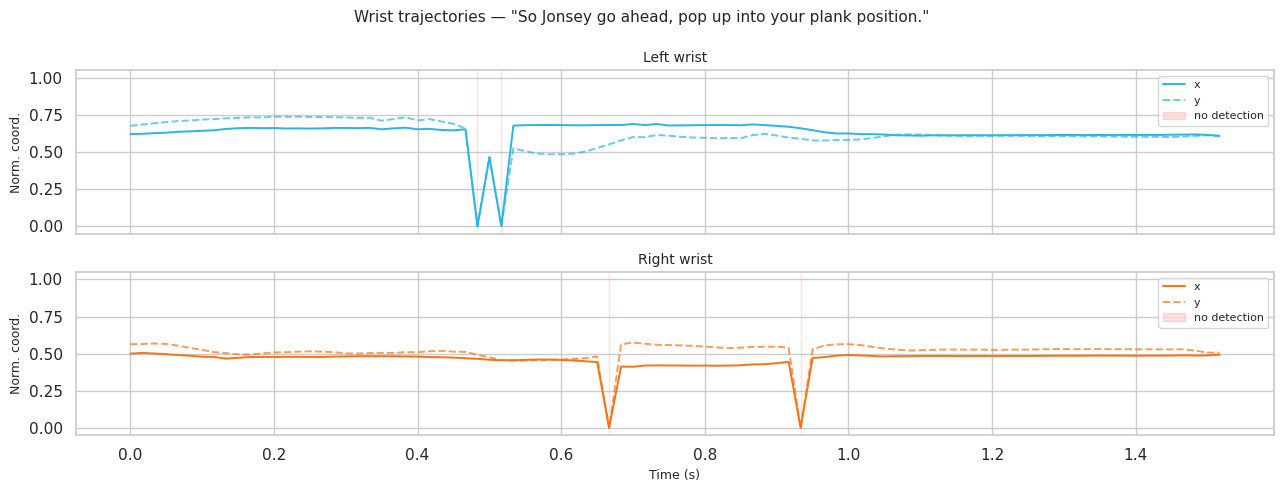

[VIZ 2] Trajectory done.


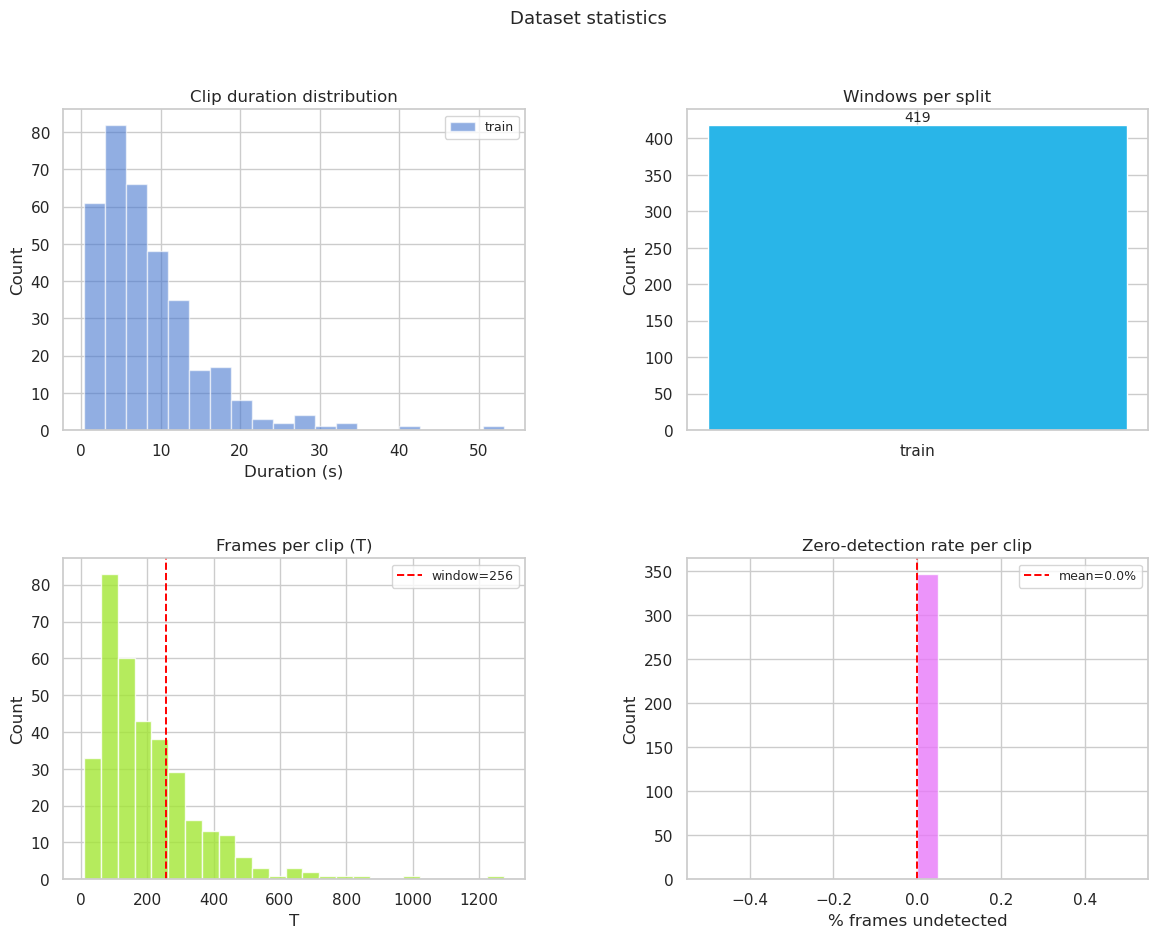

[VIZ 3] Stats done.
  Avg duration       : 8.4s
  Avg frames / clip  : 202
  Avg zero-detection : 0.0%
  Total windows      : 419


In [ ]:
# ── Pick a random clip ────────────────────────────────────────────────────────
sample_row   = manifest.sample(1).iloc[0]
sample_npy   = np.load(sample_row["npy_path"])   # (T, FEAT_DIM)
file_name    = df.loc[df["sentence_name"] == sample_row["sentence_name"], "file_name"].iloc[0]
sample_video = local / file_name
T            = sample_npy.shape[0]

print(f"Clip     : {sample_row['sentence_name']}")
print(f"Sentence : {sample_row['sentence']}")
print(f"Frames   : {T}")

# ── Skeleton connections ──────────────────────────────────────────────────────
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20)
]
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
    (27,29),(28,30),(29,31),(30,32),(27,31),(28,32)
]

def draw_landmarks_on_frame(frame, kp_row, H, W):
    canvas = frame.copy()
    lh_pts = kp_row[0  :63 ].reshape(21, 3)
    rh_pts = kp_row[63 :126].reshape(21, 3)
    po_pts = kp_row[126:225].reshape(33, 3)
    fa_pts = kp_row[225:   ].reshape(-1, 3)

    def to_px(pts):
        return [(int(p[0]*W), int(p[1]*H)) for p in pts]

    def draw_conn(c, px, conns, color, thick=1):
        for i, j in conns:
            p1, p2 = px[i], px[j]
            if p1 != (0,0) and p2 != (0,0):
                cv2.line(c, p1, p2, color, thick, cv2.LINE_AA)

    def draw_pts(c, px, color, r=3):
        for p in px:
            if p != (0,0):
                cv2.circle(c, p, r, color, -1, cv2.LINE_AA)

    po_px = to_px(po_pts)
    draw_conn(canvas, po_px, POSE_CONNECTIONS, (163,230,53),  2)
    draw_pts(canvas,  po_px, (163,230,53), 3)

    lh_px = to_px(lh_pts)
    draw_conn(canvas, lh_px, HAND_CONNECTIONS, (41,181,232), 2)
    draw_pts(canvas,  lh_px, (41,181,232), 4)

    rh_px = to_px(rh_pts)
    draw_conn(canvas, rh_px, HAND_CONNECTIONS, (249,115,22), 2)
    draw_pts(canvas,  rh_px, (249,115,22), 4)

    fa_px = to_px(fa_pts)
    draw_pts(canvas, fa_px, (232,121,249), 2)

    return canvas


# ── VIZ 1 — Annotated video ───────────────────────────────────────────────────
out_raw  = VIZ_DIR / f"{sample_row['sentence_name']}_landmarks.mp4"
out_h264 = VIZ_DIR / f"{sample_row['sentence_name']}_landmarks_h264.mp4"

cap     = cv2.VideoCapture(str(sample_video))
src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
step    = max(1, round(src_fps / TARGET_FPS))
writer  = cv2.VideoWriter(str(out_raw), cv2.VideoWriter_fourcc(*"mp4v"),
                          TARGET_FPS, (W, H))

frame_idx = kp_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    if frame_idx % step == 0 and kp_idx < len(sample_npy):
        writer.write(draw_landmarks_on_frame(frame, sample_npy[kp_idx], H, W))
        kp_idx += 1
    frame_idx += 1
cap.release()
writer.release()

# re-encode to H.264 for inline playback
try:
    subprocess.run(
        ["ffmpeg", "-y", "-i", str(out_raw),
         "-vcodec", "libx264", "-crf", "23", str(out_h264)],
        check=True, capture_output=True
    )
    play_path = out_h264
except Exception:
    play_path = out_raw   # fallback to mp4v if ffmpeg not available

print(f"[VIZ 1] Video → {play_path}")
ipy_display(Video(str(play_path), embed=True, width=640))


# ── VIZ 2 — Wrist trajectory ──────────────────────────────────────────────────
time_axis   = np.arange(T) / TARGET_FPS
lh_detected = sample_npy[:, 0:63 ].any(axis=1)
rh_detected = sample_npy[:, 63:126].any(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
fig.suptitle(f"Wrist trajectories — \"{sample_row['sentence'][:70]}\"", fontsize=11)

for ax, x_t, y_t, det, color, label in [
    (axes[0], sample_npy[:,0],  sample_npy[:,1],  lh_detected, "#29b5e8", "Left wrist"),
    (axes[1], sample_npy[:,63], sample_npy[:,64], rh_detected, "#f97316", "Right wrist"),
]:
    ax.plot(time_axis, x_t, color=color, lw=1.4, label="x")
    ax.plot(time_axis, y_t, color=color, lw=1.4, label="y", linestyle="--", alpha=0.7)
    ax.fill_between(time_axis, 0, 1, where=~det,
                    transform=ax.get_xaxis_transform(),
                    color="red", alpha=0.12, label="no detection")
    ax.set_ylabel("Norm. coord.", fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(-0.05, 1.05)

axes[1].set_xlabel("Time (s)", fontsize=9)
plt.tight_layout()
plt.show()
print("[VIZ 2] Trajectory done.")


# ── VIZ 3 — Dataset statistics ────────────────────────────────────────────────
frame_counts = []
zero_rates   = []
for _, row in manifest.iterrows():
    npy = np.load(row["npy_path"], mmap_mode="r")
    frame_counts.append(npy.shape[0])
    zero_rates.append((~npy.any(axis=1)).mean() * 100)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
for split, grp in manifest.groupby("split"):
    ax1.hist(grp["duration"], bins=20, alpha=0.6, label=split)
ax1.set_title("Clip duration distribution"); ax1.set_xlabel("Duration (s)")
ax1.set_ylabel("Count"); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
sc  = window_manifest.groupby("split").size()
bars = ax2.bar(sc.index, sc.values, color=["#29b5e8","#f97316","#a3e635"])
for b, v in zip(bars, sc.values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             str(v), ha="center", va="bottom", fontsize=10)
ax2.set_title("Windows per split"); ax2.set_ylabel("Count")

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(frame_counts, bins=25, color="#a3e635", alpha=0.8)
ax3.axvline(WINDOW_SIZE, color="red", ls="--", lw=1.4, label=f"window={WINDOW_SIZE}")
ax3.set_title("Frames per clip (T)"); ax3.set_xlabel("T")
ax3.set_ylabel("Count"); ax3.legend(fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(zero_rates, bins=20, color="#e879f9", alpha=0.8)
ax4.axvline(np.mean(zero_rates), color="red", ls="--", lw=1.4,
            label=f"mean={np.mean(zero_rates):.1f}%")
ax4.set_title("Zero-detection rate per clip")
ax4.set_xlabel("% frames undetected"); ax4.set_ylabel("Count"); ax4.legend(fontsize=9)

plt.suptitle("Dataset statistics", fontsize=13)
plt.show()

print("[VIZ 3] Stats done.")
print(f"  Avg duration       : {manifest['duration'].mean():.1f}s")
print(f"  Avg frames / clip  : {np.mean(frame_counts):.0f}")
print(f"  Avg zero-detection : {np.mean(zero_rates):.1f}%")
print(f"  Total windows      : {len(window_manifest)}")

## 10 · Pipeline recap & config snapshot

In [ ]:
ipy_display(Markdown(f"""
# 🤟 hand2string — Preprocessing Pipeline

---

## What the pipeline does

| Step | Name | Output |
|------|------|--------|
| 1 | **Download** | 347 mp4 clips from `martinctl/how2sign-asl-clips` |
| 2 | **Landmark extraction** | One `.npy` per clip — shape `(T, {FEAT_DIM})` |
| 3 | **Manifest** | `manifest.parquet` — pairs each `.npy` with its sentence & split |
| 4 | **Windowing** | Fixed `({WINDOW_SIZE}, {FEAT_DIM})` windows with 50% overlap |
| 5 | **DataLoader** | `(B, T, FEAT_DIM)` = `({BATCH_SIZE}, {WINDOW_SIZE}, {FEAT_DIM})` tensors |

---

## Feature vector layout — {FEAT_DIM} dims per frame

| Dims | Block | Content |
|------|-------|---------|
| `0 – 62` | Left hand | 21 landmarks × (x, y, z) |
| `63 – 125` | Right hand | 21 landmarks × (x, y, z) |
| `126 – 224` | Pose | 33 landmarks × (x, y, z) |
| `225 – {FEAT_DIM-1}` | Face ASL subset | {len(FACE_LANDMARKS_ASL)} landmarks × (x, y, z) |

> All coordinates normalised to **[0, 1]** by MediaPipe. Missing detections are **zero-padded**.

---

## File layout
```
data/
├── how2sign_landmarks/
│   ├── <sentence_name>.npy           # (T, {FEAT_DIM})
│   ├── manifest.parquet
│   └── preprocessing_config_snapshot.json
└── how2sign_windows/
    ├── <sentence_name>__w0000.npy    # ({WINDOW_SIZE}, {FEAT_DIM})
    └── window_manifest.parquet
```

---

## How to use in your model
```python
window_manifest = pd.read_parquet("data/how2sign_windows/window_manifest.parquet")
train_dl = DataLoader(SignLanguageWindowDataset(window_manifest, 'train'),
                      batch_size={BATCH_SIZE}, shuffle=True)

for x_batch, sentences in train_dl:
    # x_batch : ({BATCH_SIZE}, {WINDOW_SIZE}, {FEAT_DIM})  float32
    encoder_out = transformer_encoder(x_batch.permute(1, 0, 2))     # PyTorch
    outputs     = model(inputs_embeds=x_batch, labels=tokenized)    # HuggingFace
```

---

## Config snapshot

| Parameter | Value |
|-----------|-------|
| Dataset | `martinctl/how2sign-asl-clips` |
| Clips | `{len(manifest)}` |
| Windows | `{len(window_manifest)}` |
| FPS | `{TARGET_FPS}` |
| Window size | `{WINDOW_SIZE}` frames |
| Batch size | `{BATCH_SIZE}` |
| Hands | `{USE_HANDS}` |
| Pose | `{USE_POSE}` |
| Face | `{USE_FACE}` (`{FACE_SUBSET}` — {len(FACE_LANDMARKS_ASL)} landmarks) |
| Feature dim | `{FEAT_DIM}` |
"""))

snapshot = {
    "dataset"        : "martinctl/how2sign-asl-clips",
    "n_clips"        : len(manifest),
    "n_windows"      : len(window_manifest),
    "feat_dim"       : FEAT_DIM,
    "window_size"    : WINDOW_SIZE,
    "batch_size"     : BATCH_SIZE,
    "target_fps"     : TARGET_FPS,
    "use_hands"      : USE_HANDS,
    "use_pose"       : USE_POSE,
    "use_face"       : USE_FACE,
    "face_subset"    : FACE_SUBSET,
    "face_landmarks" : FACE_LANDMARKS_ASL,
    "splits"         : window_manifest.groupby("split").size().to_dict(),
}
snap_path = OUTPUT_ROOT / "preprocessing_config_snapshot.json"
with open(snap_path, "w") as f:
    json.dump(snapshot, f, indent=2)

print(f"Config snapshot → {snap_path}")
print("Pipeline complete ✓")


# 🤟 hand2string — Preprocessing Pipeline

---

## What the pipeline does

| Step | Name | Output |
|------|------|--------|
| 1 | **Download** | 347 mp4 clips from `martinctl/how2sign-asl-clips` |
| 2 | **Landmark extraction** | One `.npy` per clip — shape `(T, 384)` |
| 3 | **Manifest** | `manifest.parquet` — pairs each `.npy` with its sentence & split |
| 4 | **Windowing** | Fixed `(256, 384)` windows with 50% overlap |
| 5 | **DataLoader** | `(B, T, FEAT_DIM)` = `(8, 256, 384)` tensors |

---

## Feature vector layout — 384 dims per frame

| Dims | Block | Content |
|------|-------|---------|
| `0 – 62` | Left hand | 21 landmarks × (x, y, z) |
| `63 – 125` | Right hand | 21 landmarks × (x, y, z) |
| `126 – 224` | Pose | 33 landmarks × (x, y, z) |
| `225 – 383` | Face ASL subset | 53 landmarks × (x, y, z) |

> All coordinates normalised to **[0, 1]** by MediaPipe. Missing detections are **zero-padded**.

---

## File layout
```
data/
├── how2sign_landmarks/
│   ├── <sentence_name>.npy           # (T, 384)
│   ├── manifest.parquet
│   └── preprocessing_config_snapshot.json
└── how2sign_windows/
    ├── <sentence_name>__w0000.npy    # (256, 384)
    └── window_manifest.parquet
```

---

## How to use in your model
```python
window_manifest = pd.read_parquet("data/how2sign_windows/window_manifest.parquet")
train_dl = DataLoader(SignLanguageWindowDataset(window_manifest, 'train'),
                      batch_size=8, shuffle=True)

for x_batch, sentences in train_dl:
    # x_batch : (8, 256, 384)  float32
    encoder_out = transformer_encoder(x_batch.permute(1, 0, 2))     # PyTorch
    outputs     = model(inputs_embeds=x_batch, labels=tokenized)    # HuggingFace
```

---

## Config snapshot

| Parameter | Value |
|-----------|-------|
| Dataset | `martinctl/how2sign-asl-clips` |
| Clips | `347` |
| Windows | `419` |
| FPS | `60` |
| Window size | `256` frames |
| Batch size | `8` |
| Hands | `True` |
| Pose | `True` |
| Face | `True` (`asl` — 53 landmarks) |
| Feature dim | `384` |


Config snapshot → /home/louis/epfl/ma2/cs/hand2string/data/how2sign_landmarks/preprocessing_config_snapshot.json
Pipeline complete ✓
